In [1]:
import os
import re
import glob
import unicodedata
from collections import Counter

RAW = "corpus_raw"
CLEAN = "corpus_clean"
LEMMA = "corpus_lemma"
LEXDIR = "lexicon"
BUCKETS = ("sastra", "arsip", "jurnal", "majalah")
import matplotlib.pyplot as plt


- sastra - литература (основной корпус), 
- jurnal - журналы 1920-30-х,
- arsip - архивы
- majalah - журнал Panjebar Semangat 2010-х. Тексты из папки _recovered - без категории

In [2]:
RECOVERED_JURNAL = re.compile(
    r"kajaw[eè]n|pusaka jawi|s[eê]dya tama|darma kanda|narpawandawa|"
    r"waspada|panji pustaka", re.I)
RECOVERED_ARSIP = re.compile(r"koleksi warsadiningrat|arsip", re.I)

def bucket_of(relpath, title=""):
    if relpath.startswith("sastra-org/arsip-dan-sejarah"):
        return "arsip"
    if relpath.startswith("sastra-org/koran-majalah-dan-jurnal"):
        return "jurnal"
    if relpath.startswith("sastra-org/_recovered"):
        if RECOVERED_JURNAL.search(title):
            return "jurnal"
        if RECOVERED_ARSIP.search(title):
            return "arsip"
        return "sastra"
    if relpath.startswith("panjebarsemangat/"):
        return "majalah"
    return "sastra"

Словари, грамматики и списки слов выкидываем по названию

In [3]:
EXCLUDE_TITLE = re.compile(
    r"dictionary|dictionnaire|woordenboek|wordenboek|kamus|leksikon|"
    r"paramasastra|spraakkunst|synoniemen|grammatica|dasanama|"
    r"javaansch.*taal|woordenlijst|pangkalan.?data|wawaton.?panyerat|"
    r"frekuensi.?kata", re.I)

По стоп словам определяем и выкидываем строки

In [4]:
JAV = {"ing", "kang", "iku", "ora", "lan", "saka", "karo", "wis", "ana",
       "iki", "kanthi", "dening", "marang", "sing", "ingkang", "punika",
       "menika", "wonten", "boten", "mboten", "sampun", "dhateng", "saking",
       "ugi", "inggih", "kaliyan", "dene", "yen", "menawa", "menawi",
       "nanging", "amarga", "amargi", "supaya", "supados", "banjur",
       "lajeng", "uga", "apa", "punapa", "kados", "kaya", "sarta", "tuwin",
       "utawi", "utawa", "datan", "tan", "kalawan", "miwah", "ingsun",
       "sira", "dadya", "dadi", "dados", "arsa", "badhe", "bakal", "wus",
       "sampun", "maring", "aneng", "neng", "ono", "iso", "isa", "ake",
       "dhumateng", "kagem", "dhewe", "piyambak", "malih", "maneh",
       "sanget", "banget", "mawi", "tanpa", "sajroning", "salebeting"}
IND = {"yang", "dengan", "tidak", "dari", "untuk", "pada", "adalah",
       "dalam", "dan", "akan", "sudah", "telah", "bisa", "karena",
       "mereka", "kita", "saya", "anda", "tersebut", "sebagai", "juga",
       "atau", "itu", "ini", "oleh", "ke", "di", "secara", "tetapi",
       "namun", "agar", "supaya", "jika", "kalau", "saat", "ketika",
       "sehingga", "kemudian", "yaitu", "ialah", "bahwa", "para",
       "merupakan", "terhadap", "seperti", "antara", "banyak", "lebih"}
ENG = {"the", "of", "and", "to", "in", "is", "was", "for", "with", "that",
       "this", "are", "be", "or", "from", "by", "an", "not", "his", "her"}
DUT = {"de", "het", "van", "en", "een", "der", "den", "te", "dat", "die",
       "met", "voor", "zijn", "aan", "op", "is", "niet", "ook", "naar",
       "worden", "wordt", "deze", "bij", "uit", "over", "tot"}
AMBIG = JAV & IND
JAVX, INDX = JAV - AMBIG, IND - AMBIG

PRONOUNS = {"aku", "kula", "kawula", "ingsun", "ingwang", "kowe", "kowé",
            "sira", "sampeyan", "panjenengan", "panjenenganipun",
            "dheweke", "dheke", "piyambakipun", "kita", "awakmu",
            "awakku", "slirane", "sliramu"}

Выкидываем артефакты отцифровки

In [5]:
PAGE_MARK = re.compile(r"^---\s*.+?\s*---$")
PUPUH_HEAD = re.compile(r"^\d+\.?\s+[A-Za-zÀ-ÿê]+\s*$")
NUM_ONLY = re.compile(r"^[\d\s.\-:()\[\]]+$")
EDITORIAL = re.compile(
    r"^§|teks asli\s*:|kurang satu|lebih satu|kirang sa|langkung sa|"
    r"prayoginipun|kembali\)|^sambungan$|^citra$|^judul$|tanggal masehi|"
    r"^lingkup pencarian|^teks pencarian|^filter pencarian", re.I)
BROKEN_WORD = re.compile(r"\[[^\]\[]*\.\.\.[^\]\[]*\]")
FOOTNOTE_REF = re.compile(r"\[\s*\d+\s*\]")

def is_notation_line(line):
    toks = line.split()
    if len(toks) < 3:
        return False
    dig = sum(1 for t in toks if any(c.isdigit() for c in t))
    return dig / len(toks) > 0.5

def lang_score(line):
    words = re.findall(r"[a-zà-ÿêèéåăôíìóòúùṭḍ]+", line.lower())
    j = sum(1 for w in words if w in JAVX)
    i = sum(1 for w in words if w in INDX)
    e = sum(1 for w in words if w in ENG)
    d = sum(1 for w in words if w in DUT)
    return j, i + e + d

Переводим яванский к одному виду
- нижний регистр
- сворачиваем диакритику (ê-e, å-a),
- переводим довоенную орфографию в современную (oe в u, tj в c, dj в j),
- склеиваем мягкие переносы внутри слов

In [6]:
FOLD = str.maketrans({
    "ê": "e", "è": "e", "é": "e", "ë": "e",
    "å": "a", "ă": "a", "â": "a", "à": "a", "á": "a",
    "í": "i", "ì": "i", "î": "i", "ï": "i",
    "ó": "o", "ò": "o", "ô": "o", "ö": "o",
    "ú": "u", "ù": "u", "û": "u", "ü": "u",
    "ñ": "n", "ç": "c"})

def normalize(text):
    text = text.replace("\xad", "")
    text = text.lower().translate(FOLD)
    text = unicodedata.normalize("NFKD", text)
    text = "".join(c for c in text if not unicodedata.combining(c))
    text = re.sub(r"oe", "u", text)
    text = re.sub(r"tj", "c", text)
    text = re.sub(r"dj", "j", text)
    return text

Числа заменяем на ORDINAL1, местоимения на PRON1.
Дефис внутри слова сохраняем - это яванские удвоения (tata-tata).
Предложения режем по ".?!;" и по стиховым разделителям "|" и "||".

In [7]:
def tokenize(sentence):
    out = []
    for tok in re.findall(r"[a-z]+(?:-[a-z]+)*|\d+", sentence):
        if tok.isdigit():
            out.append("ORDINAL1")
        elif tok in PRONOUNS:
            out.append("PRON1")
        else:
            out.append(tok)
    return out

SENT_SPLIT = re.compile(r"(?<=[.?!;])\s+|\s*\|\|\s*|\s*\|\s*")

Очистка одного файла, по порядку:
- выкидываем мусорные строки
- оставляем только яванские (строка без стоп-слов наследует язык предыдущей)
- нормализуем
- режем на предложения (берём от 3 токенов и не "разрядку" заголовков типа "п а н г к у р")

In [8]:
def clean_file(path):
    lines = open(path, encoding="utf-8", errors="replace").read().split("\n")
    body = lines[1:]
    kept, prev_jav = [], True
    for ln in body:
        ln = ln.strip()
        if not ln:
            continue
        if (PAGE_MARK.match(ln) or NUM_ONLY.match(ln) or
                ln in ("[", "]") or EDITORIAL.search(ln) or
                PUPUH_HEAD.match(ln) or is_notation_line(ln)):
            continue
        ln = BROKEN_WORD.sub(" ", ln)
        ln = FOOTNOTE_REF.sub(" ", ln)
        j, o = lang_score(ln)
        if j + o == 0:
            keep = prev_jav
        else:
            keep = j > o
            prev_jav = keep
        if keep:
            kept.append(ln)
    sentences = []
    for ln in kept:
        for s in SENT_SPLIT.split(normalize(ln)):
            toks = tokenize(s)
            if len(toks) >= 3 and \
                    sum(1 for t in toks if len(t) == 1) <= len(toks) // 2:
                sentences.append(toks)
    return sentences

Прогон очистки по всем файлам corpus_raw (~10 минут).
Целиком выкидываем словари/грамматики и то, где после очистки осталось меньше 30 токенов (нотации гамелана, заглушки). Результат - в corpus_clean.

In [9]:
os.makedirs(CLEAN, exist_ok=True)
excluded, stats = [], Counter()
corp_text = {b: open(os.path.join(CLEAN, f"corpus_text_{b}.txt"), "w",
                     encoding="utf-8") for b in BUCKETS}
corp_seg = {b: open(os.path.join(CLEAN, f"corpus_segments_{b}.txt"), "w",
                    encoding="utf-8") for b in BUCKETS}

for dirp, _, files in os.walk(RAW):
    for fn in sorted(files):
        if not fn.endswith(".txt") or fn.startswith("_"):
            continue
        src = os.path.join(dirp, fn)
        rel = os.path.relpath(src, RAW)
        title = open(src, encoding="utf-8", errors="replace").readline().strip()
        if EXCLUDE_TITLE.search(title) or EXCLUDE_TITLE.search(fn):
            excluded.append((rel, "dictionary/grammar/wordlist"))
            continue
        b = bucket_of(rel, title)
        sents = clean_file(src)
        ntok = sum(len(s) for s in sents)
        if ntok < 30:
            excluded.append((rel, f"too short after cleaning ({ntok} tok)"))
            continue
        flat = rel.replace("/", "__")
        os.makedirs(os.path.join(CLEAN, "texts", b), exist_ok=True)
        with open(os.path.join(CLEAN, "texts", b, flat), "w",
                  encoding="utf-8") as f:
            for s in sents:
                f.write(" ".join(s) + "\n")
        corp_text[b].write(" ".join(" ".join(s) for s in sents) + "\n")
        for s in sents:
            corp_seg[b].write(" ".join(s) + "\n")
        stats[b + "_files"] += 1
        stats[b + "_tokens"] += ntok
        stats[b + "_sents"] += len(sents)

for f in list(corp_text.values()) + list(corp_seg.values()):
    f.close()
with open(os.path.join(CLEAN, "_excluded.tsv"), "w", encoding="utf-8") as f:
    f.write("file\treason\n")
    for r, why in excluded:
        f.write(f"{r}\t{why}\n")
with open(os.path.join(CLEAN, "_stats.txt"), "w", encoding="utf-8") as f:
    for k in sorted(stats):
        f.write(f"{k}: {stats[k]}\n")
    f.write(f"excluded_files: {len(excluded)}\n")

for k in sorted(stats):
    print(f"{k}: {stats[k]}")
print("исключено файлов:", len(excluded))

arsip_files: 386
arsip_sents: 181199
arsip_tokens: 1630948
jurnal_files: 682
jurnal_sents: 299590
jurnal_tokens: 3834223
majalah_files: 2224
majalah_sents: 126512
majalah_tokens: 1234437
sastra_files: 2105
sastra_sents: 2254719
sastra_tokens: 13830816
исключено файлов: 792


Лемматизация. Принцип: сними аффикс - проверь, что получился существующий корень.
Лексикон корней собираем из словарей, лежащих в сыром корпусе (в текстовый корпус они не вошли, а тут пригодились):
- Javanese-English Dictionary, E. C. Horne, 1974 (заголовочные слова; основной современный словарь, 31 файл со sastra.org)
- Javaansch-Nederduitsch Woordenboek, Gericke & Roorda, 1847 (20 частей; самый полный словарь яванского XIX века, даёт классическую лексику; перенаправления "zie X" не берём)
- списки синонимов dasanama - старинная поэтическая лексика (кави): Dasanama Kawi (Padmasusastra, 1897), Kawi Dasanama (Winter, 1875; аноним, 1882), Dasanamajarwa (Dirjaatmaja, 1913 и 1916; Tjokrodipuro, 1970), Dasanama mawi Jarwa (аноним, 1904), Dasanama (аноним, 1932; Dwijo, 1950)

Заодно считаем частоты слов корпуса - пригодятся для выбора между кандидатами.

In [10]:
WORD = re.compile(r"^[a-zà-ÿêèéåăṭḍ]+(?:-[a-zà-ÿêèéåăṭḍ]+)*$")
HORNE_NOISE = {"a", "b", "c", "ng", "kr", "ki", "ka", "var", "rg", "ltry",
               "inf", "sms", "see", "also", "or", "oj", "kn", "md"}

def horne_headwords():
    words = set()
    files = glob.glob(os.path.join(
        RAW, "sastra-org", "*", "*javanese-english-dictionary-horne*.txt"))
    for path in files:
        for ln in open(path, encoding="utf-8", errors="replace"):
            w = ln.strip().lower()
            if (not w or " " in w or len(w) < 3 or w in HORNE_NOISE or
                    w.startswith("-") or w.endswith("-")):
                continue
            if WORD.match(w):
                words.add(normalize(w))
    return words

def dasanama_words():
    words = set()
    files = glob.glob(os.path.join(RAW, "sastra-org", "*", "*dasanama*.txt"))
    for path in files:
        for ln in open(path, encoding="utf-8", errors="replace"):
            ln = ln.strip()
            if ln.startswith("---"):
                continue
            if ln.endswith(":") and len(ln.split()) <= 3:
                ln = ln.rstrip(" :")
            elif "|" not in ln:
                continue
            for w in re.split(r"[|,.()]| ", ln):
                w = w.strip().lower()
                if len(w) >= 3 and WORD.match(w):
                    words.add(normalize(w))
    return words

def gericke_headwords():
    words = set()
    files = glob.glob(os.path.join(RAW, "sastra-org", "*", "*gericke*.txt"))
    for path in files:
        lines = [l.strip() for l in
                 open(path, encoding="utf-8", errors="replace")]
        for i, ln in enumerate(lines):
            if not ln.endswith(":"):
                continue
            w = ln.rstrip(" :").lower()
            if len(w) < 3 or not WORD.match(w):
                continue
            nxt = lines[i + 1] if i + 1 < len(lines) else ""
            if nxt.lower().startswith("zie ") and len(nxt) < 60:
                continue
            words.add(normalize(w))
    return words

os.makedirs(LEXDIR, exist_ok=True)
horne = horne_headwords()
dasa = dasanama_words()
gericke = gericke_headwords()
roots_all = horne | dasa | gericke
with open(os.path.join(LEXDIR, "roots.txt"), "w", encoding="utf-8") as f:
    for w in sorted(roots_all):
        f.write(w + "\n")

freq_cnt = Counter()
for b in BUCKETS:
    p = os.path.join(CLEAN, f"corpus_segments_{b}.txt")
    if os.path.exists(p):
        for ln in open(p, encoding="utf-8"):
            freq_cnt.update(ln.split())
with open(os.path.join(LEXDIR, "freq.tsv"), "w", encoding="utf-8") as f:
    for w, c in freq_cnt.most_common():
        if c >= 3:
            f.write(f"{w}\t{c}\n")

print(f"Horne: {len(horne)}, dasanama: {len(dasa)}, "
      f"Gericke-Roorda: {len(gericke)}, корней: {len(roots_all)}")

Horne: 12362, dasanama: 5583, Gericke-Roorda: 9293, корней: 22421


Снятие аффиксов разнесено на две группы (ячейка ниже):
- **инфлексия** (грамматика) - снимаем, формы одного слова склеиваются: залог в префиксах (N-, di-/dipun-, ka-, tak-/dak-, kok-), инфиксы -um-/-in-, определённость/принадлежность/наклонение и стиховые линкеры в суффиксах (-e/-ipun/-ku/-mu, -a/-en, -(n)ing/-(n)ira), редупликация (omah-omah → omah)
- **деривация** (меняет значение) - НЕ снимаем, остаётся отдельной леммой: номинализатор -an (tulisan «текст» ≠ tulis «писать», inuman «напиток» ≠ inum «пить»), каузатив -ake/-aken, аппликатив -i, отглагольные/отыменные префиксы pa-/pe-/pi-/pra-/sa-/ke- и их назальные варианты (pan-/pang-/pen-/...). Эти аффиксы снимаются только при проверке, что основа сводится к корню
- назальный префикс восстанавливает первую согласную корня (nulis → tulis) перебором кандидатов; для основ из назальной подмены деривация проверяется только суффиксами (иначе фантомы вида militer → pi+liter)
- **морфофонемика** на стыке корня и суффикса: конечный гласный корня восстанавливается (kali+an → kalen, telu+an → telon, dadi+kake → dadekake, gawe+an → gaweyan), линкер -k- в императиве (temokna → temu), элизия ke- (k(e)rasa → rasa)

In [11]:
# Аффиксы разнесены на инфлексию и деривацию.
# Инфлексия (снимаем -> формы одного слова склеиваются): залог/лицо в
# префиксах; определённость/принадлежность/наклонение и стиховые линкеры в
# суффиксах; плюс структурные операции - назализация, инфиксы, редупликация.
INFL_SUFFIXES = ["nipun", "ipun", "ning", "nira", "ana", "ing", "ira",
                 "na", "ne", "en", "e", "a", "ku", "mu"]
INFL_PREFIXES = ["dipun", "di", "ka", "tak", "dak", "kok"]
# Деривация (НЕ снимаем -> остаётся отдельной леммой, т.к. меняет значение):
# номинализатор -an, каузатив -ake/-aken, аппликатив -i; отглагольные и
# отыменные префиксы pa-/pe-/pi-/pra-/sa-/ke-/kuma-/a- и их назальные формы
# pan-/pang-/pam-/pany-/pen-/.../per-, разговорное sak-. Снимаются ТОЛЬКО при
# проверке, что основа сводится к настоящему корню (см. Lemmatizer).
DER_SUFFIXES = ["kaken", "kake", "aken", "ake", "yan", "wan", "an", "en",
                "on", "ni", "i"]
DER_PREFIXES = ["pra", "kuma", "pang", "pany", "pam", "pan", "peng", "peny",
                "pem", "pen", "per", "sak", "pa", "pe", "pi", "sa",
                "ke", "a"]
VOWELS = "aeiou"
SPECIALS = {"ORDINAL1", "PRON1"}
# Частые лексикализованные слова, которых нет в словарях-источниках (Horne и
# др.) - иначе разбираются ошибочно (minangka -> mangka, mangkono ->
# pang+kono и т.п.). Защищаем их как корни (плюс служебный набор JAV и
# закрытый класс PRONOUNS добавляются в Lemmatizer).
PROTECT = {"minangka", "negara", "melu", "mbok", "makarya", "tumunten",
           "kawontenan", "mangsa", "menapa",
           "mangkono", "mangkana", "kayata"}

def _vowel_variants(stem):
    # восстановление конечного гласного корня перед суффиксом:
    # kali+an -> kalen, telu+an -> telon, dadi+kake -> dadekake
    out = []
    if stem and stem[-1] == "e":
        out.append(stem[:-1] + "i")
    elif stem and stem[-1] == "o":
        out.append(stem[:-1] + "u")
        out.append(stem[:-1] + "a")
    return out

def nasal_candidates(w):
    out = []
    if w.startswith("nj"):
        out.append(w[1:])
    elif w.startswith("nge") and len(w) <= 7:
        out.append(w[3:])
    if w.startswith("ng"):
        out.append(w[2:])
        out.append("k" + w[2:])
    elif w.startswith("ny"):
        out.append("s" + w[2:])
        out.append("c" + w[2:])
    elif w.startswith("mb") or (len(w) > 1 and w[0] == "m" and w[1] in "lr"):
        out.append(w[1:])
    elif w.startswith("m"):
        out.append("p" + w[1:])
        out.append("w" + w[1:])
    elif w.startswith("nd"):
        out.append(w[1:])
    elif w.startswith("n"):
        out.append("t" + w[1:])
        out.append("th" + w[1:])
        if len(w) > 1 and w[1] in VOWELS:
            out.append(w[1:])            # n+гласная: niku -> iku (madya)
    return out

def redup_candidates(w):
    out = []
    if "-" in w:
        parts = w.split("-")
        if len(parts) == 2 and parts[0] and parts[1]:
            if parts[0] == parts[1] or len(parts[0]) == len(parts[1]):
                out.append(parts[1])
        return out
    # dwipurwa - редупликация первого слога с pepet 'e' (lelaku->laku,
    # sesaji->saji). Только 'e': шаблон C-a-C ложно срабатывал (nandhang).
    if len(w) > 4 and w[0] == w[2] and w[1] == "e":
        out.append(w[2:])
    return out

def infl_candidates(w):
    """Снять одну инфлексию или структурную операцию - для получения леммы."""
    out = list(redup_candidates(w))
    if "-" in w:
        return out
    for s in INFL_SUFFIXES:
        if w.endswith(s) and len(w) - len(s) >= 3:
            out.append(w[:-len(s)])
    for p in INFL_PREFIXES:
        if w.startswith(p) and len(w) - len(p) >= 3:
            out.append(w[len(p):])
    out.extend(c for c in nasal_candidates(w) if len(c) >= 3)
    if len(w) >= 5 and w[1:3] in ("um", "in"):   # инфиксы -um-/-in-
        out.append(w[0] + w[3:])
    return out

def linker_candidates(w):
    """Линкер -k- между корнем и суффиксом (temokna -> temu, ditinggalke ->
    ditinggal, разговорное -ke = -ake). В lemma() считается за ОТДЕЛЬНОЕ
    снятие (глубже на 1), чтобы при притяжательных не съедалась конечная k
    корня: anake -> anak (мельче), а не ana."""
    out = []
    for s in INFL_SUFFIXES:
        if w.endswith("k" + s) and len(w) - len(s) - 1 >= 3:
            stem = w[:-len(s) - 1]
            out.append(stem)
            out.extend(_vowel_variants(stem))
    return out

def der_candidates(w, no_prefix=False):
    """Снять одну деривацию - только для проверки основы, не для вывода.
    no_prefix: для основ, полученных назальной подменой (m->p и т.п.),
    префиксную деривацию не снимаем - иначе фантомные разборы вида
    militer -> pi+liter."""
    if "-" in w:
        return []
    out = []
    for s in DER_SUFFIXES:
        if w.endswith(s) and len(w) - len(s) >= 3:
            stem = w[:-len(s)]
            if s == "en":
                # -en = гласный корня + -an: kalen -> kali; голую основу не
                # даём, чтобы императив (pikiren) не выглядел деривацией
                out.append(stem + "i")
            elif s == "on":
                out.extend([stem + "o", stem + "u"])  # jeron->jero, telon->telu
            else:
                out.append(stem)
                out.extend(_vowel_variants(stem))
    if no_prefix:
        return out
    for p in DER_PREFIXES:
        if w.startswith(p) and len(w) - len(p) >= 3:
            rest = w[len(p):]
            out.append(rest)
            # pa-/pe- + назализация: penembak -> pe+n(t)embak -> tembak
            if p in ("pa", "pe"):
                out.extend(c for c in nasal_candidates(rest) if len(c) >= 3)
    # ke- с элизией/слиянием гласного: k(e)rasa -> rasa, k+eling(an) -> eling
    if len(w) >= 4 and w[0] == "k":
        if w[1] in "lr":
            out.append(w[1:])
        elif w[1] == "e":
            out.append(w[1:])
    return out

def _looks_inflected(w, base_roots, freq, ratio=10):
    """Слово - явная флексия известного словарного корня, а само по корпусу
    много реже основы (wise 200 против wis 35 тыс. - англ. глосса из Horne).
    Частотное условие оставляет в покое настоящие корни, чьё усечение
    случайно совпало со словом (usaha/usah, kene/ken)."""
    def ok_stem(st):
        return (len(st) >= 3 and st in base_roots
                and (len(st) >= 4 or freq.get(st, 0) >= 500)
                and freq.get(w, 0) * ratio < freq.get(st, 0))
    cands = list(nasal_candidates(w))
    for s in INFL_SUFFIXES:
        if w.endswith(s):
            cands.append(w[:-len(s)])
    for p in INFL_PREFIXES:
        if w.startswith(p):
            cands.append(w[len(p):])
    return any(ok_stem(c) for c in cands)

NAS_FWD = {"t": "n", "p": "m", "k": "ng", "s": "ny", "c": "ny", "w": "m",
           "b": "m", "d": "n", "g": "ngg", "j": "nj"}

def surface_variants(w):
    """Словоформы, которые корень w закономерно порождает в корпусе
    (для добычи корней, отсутствующих в словарях)."""
    out = [p + w for p in ("di", "dipun", "tak", "ka")]
    if w[-1] in VOWELS:
        out += [w + "ne", w + "nipun", w + "kake"]
    else:
        out += [w + "e", w + "ipun", w + "ake"]
    out += [w + "an", w + "i", w + "a", w + "en"]
    c = w[0]
    if c in VOWELS:
        out.append("ng" + w)
    elif c in NAS_FWD:
        out.append(NAS_FWD[c] + (w if c in "bdgj" else w[1:]))
    return out

Лемматизатор в две фазы. Фаза 1 - снимаем у слова только инфлексию (поиск в ширину, цепочки до 3 снятий): получаем основу без грамматики, но с деривацией. Фаза 2 - проверяем, что основа реальна: сводится ли она к корню из лексикона снятием уже деривации. Лемма - самая «мелкая» основа (минимум снятой инфлексии), прошедшая проверку; из нескольких берём корень / самый частотный. Ничего не сошлось - слово оставляем как есть, чтобы не испортить.
Очень частые короткие слова не трогаем (служебные); редкие трёхбуквенные корни не принимаем (среди них много ложных).

Лексикон при инициализации дочищается и пополняется:
- из словарных корней выбрасываются протёкшие английские глоссы и флексии (wise, liyane): слово, которое разбирается как флексия известного корня и при этом заметно реже него, - не корень
- **добыча корней из корпуса**: слово, которое лемматизатор не разбирает, но у которого в корпусе живут >=3 закономерных словоформ (diX, Xe/Xipun, назальная форма...), принимается корнем (omong, mligi, kinten - словари-источники их не знают). Идём от частых к редким, чтобы принятый корень сразу закрывал свои же формы (ngomong не станет корнем, раз есть omong)

In [12]:
class Lemmatizer:
    def __init__(self, lexdir=LEXDIR):
        dict_roots = set(
            open(os.path.join(lexdir, "roots.txt"), encoding="utf-8")
            .read().split())
        self.freq = {}
        for ln in open(os.path.join(lexdir, "freq.tsv"), encoding="utf-8"):
            w, c = ln.rsplit("\t", 1)
            self.freq[w] = int(c)
        # защищаем служебные (JAV), местоимения (закрытый класс) и частые
        # лексикализованные слова (PROTECT), которых нет в словарях
        base = dict_roots | JAV | PROTECT | PRONOUNS
        # чистка словарных корней: из Horne протекают английские глоссы и
        # флексии (wise блокировал sawise -> wis)
        dict_roots = {w for w in dict_roots
                      if self.freq.get(w, 0) >= 500
                      or not _looks_inflected(w, base, self.freq)}
        base = dict_roots | JAV | PROTECT | PRONOUNS
        # частотная добавка - с фильтром от флексий (liyane блокировал
        # saliyane -> saliya): порог ratio=1, т.е. форма реже основы
        freq_add = {w for w, c in self.freq.items()
                    if c >= 3000 and 3 <= len(w) <= 7 and w.isalpha()
                    and not _looks_inflected(w, base, self.freq, ratio=1)}
        self.roots = base | freq_add
        self.cache, self.rcache = {}, {}
        self.mined = self._mine_roots()
        self.roots |= self.mined
        self.cache, self.rcache = {}, {}

    def _mine_roots(self):
        """Корни, которых нет в словарях (omong, mligi): слово частое,
        лемматизатор его не разбирает, а в корпусе живут >=3 его
        закономерных словоформ. Идём от частых к редким без кэша, чтобы
        принятый корень (omong) сразу закрывал свои формы (ngomong)."""

        def reduces_fresh(stem):
            frontier, seen = [stem], {stem}
            for _ in range(4):
                if any(self._is_root(w) for w in frontier):
                    return True
                frontier = [c for w in frontier for c in der_candidates(w)
                            if c not in seen and len(c) >= 3
                            and not seen.add(c)]
                if not frontier:
                    break
            return False

        def handled(w):
            stems, frontier = {w}, [w]
            for _ in range(3):
                frontier = [c for x in frontier for c in infl_candidates(x)
                            if c not in stems and len(c) >= 3
                            and not stems.add(c)]
                if not frontier:
                    break
            return any(s in self.roots or (s != w and reduces_fresh(s))
                       for s in stems)

        mined = set()
        for w, c in sorted(self.freq.items(), key=lambda x: (-x[1], x[0])):
            if c < 30:
                break
            if w in self.roots or not w.isalpha() or not 4 <= len(w) <= 9:
                continue
            if reduces_fresh(w) or handled(w):
                continue
            if sum(1 for v in surface_variants(w)
                   if self.freq.get(v, 0) >= 5) >= 3:
                mined.add(w)
                self.roots.add(w)
        return mined

    def _is_root(self, w):
        return w in self.roots and (len(w) >= 4 or self.freq.get(w, 0) >= 500)

    def _reduces_to_root(self, stem, no_prefix=False):
        # реальна ли основа: сводится ли к корню снятием ТОЛЬКО деривации?
        key = (stem, no_prefix)
        if key in self.rcache:
            return self.rcache[key]
        ok = self._is_root(stem)
        frontier, seen = [stem], {stem}
        for _ in range(3):
            if ok:
                break
            nxt = []
            for w in frontier:
                for c in der_candidates(w, no_prefix):
                    if c in seen or len(c) < 3:
                        continue
                    if self._is_root(c):
                        ok = True
                        break
                    seen.add(c)
                    nxt.append(c)
                if ok:
                    break
            frontier = nxt
            if not frontier:
                break
        self.rcache[key] = ok
        return ok

    def lemma(self, tok):
        if tok in SPECIALS or len(tok) < 4 or tok in self.roots:
            return tok
        if self.freq.get(tok, 0) >= 5000 and len(tok) <= 7:
            return tok
        if tok in self.cache:
            return self.cache[tok]
        # Фаза 1: снимаем ТОЛЬКО инфлексию -> основы с глубиной снятия;
        # помечаем основы, полученные назальной подменой (taint) - для них
        # деривация в фазе 2 проверяется только суффиксами.
        depth, frontier = {tok: (0, False)}, [tok]
        for d in range(1, 4):
            nxt = []
            for w in frontier:
                nas = set(nasal_candidates(w))
                for c in infl_candidates(w):
                    if c in depth or len(c) < 3:
                        continue
                    depth[c] = (d, depth[w][1] or c in nas)
                    nxt.append(c)
                for c in linker_candidates(w):
                    if c in depth or len(c) < 3:
                        continue
                    depth[c] = (d + 1, depth[w][1])   # линкер = лишнее снятие
                    nxt.append(c)
            frontier = nxt
            if not frontier:
                break
        # Фаза 2: лемма = самая «мелкая» основа (минимум снятой инфлексии),
        # которая сводится к корню; тай-брейк - корень/частота. Деривацию
        # сохраняем: tulisan, inuman остаются собой. Ничего не сошлось -
        # слово не трогаем, чтобы не испортить.
        cands = [s for s in depth
                 if self._reduces_to_root(s, no_prefix=depth[s][1])]
        res = min(cands, key=lambda s: (depth[s][0], -(s in self.roots),
                                        -self.freq.get(s, 0))) if cands else tok
        self.cache[tok] = res
        return res

lem = Lemmatizer()
print(f"корней: {len(lem.roots)}, из них добыто из корпуса: {len(lem.mined)}")
print("деривация остаётся:  tulisan ->", lem.lemma("tulisan"),
      "| inuman ->", lem.lemma("inuman"))
print("инфлексия снимается: nulis ->", lem.lemma("nulis"),
      "| tulisane ->", lem.lemma("tulisane"),
      "| inumane ->", lem.lemma("inumane"))
print("морфофонемика:       kalene ->", lem.lemma("kalene"),
      "| ndadekake ->", lem.lemma("ndadekake"),
      "| sawise ->", lem.lemma("sawise"))
print("добытые корни:       ngomong ->", lem.lemma("ngomong"),
      "| защита частых: minangka ->", lem.lemma("minangka"),
      "| negara ->", lem.lemma("negara"))

корней: 22452, из них добыто из корпуса: 318
деривация остаётся:  tulisan -> tulisan | inuman -> inuman
инфлексия снимается: nulis -> tulis | tulisane -> tulisan | inumane -> inuman
морфофонемика:       kalene -> kalen | ndadekake -> dadekake | sawise -> sawis
добытые корни:       ngomong -> omong | защита частых: minangka -> minangka | negara -> negara


Прогон лемматизатора по очищенному корпусу: corpus_clean -> corpus_lemma (та же структура - тексты по файлам в texts/<ведро>/, текстовый corpus_text_<ведро>.txt и сегментный corpus_segments_<ведро>.txt). Заодно считаем размер словаря до и после по каждому ведру и пишем в _stats.txt строки вида `<ведро>_vocab: было->стало`. Несколько минут.

In [13]:
os.makedirs(LEMMA, exist_ok=True)
lem_stats = Counter()
vocab_before, vocab_after = {}, {}

for b in BUCKETS:
    src_dir = os.path.join(CLEAN, "texts", b)
    if not os.path.isdir(src_dir):
        continue
    os.makedirs(os.path.join(LEMMA, "texts", b), exist_ok=True)
    vb, va = set(), set()
    ct = open(os.path.join(LEMMA, f"corpus_text_{b}.txt"), "w",
              encoding="utf-8")
    cs = open(os.path.join(LEMMA, f"corpus_segments_{b}.txt"), "w",
              encoding="utf-8")
    for fn in sorted(os.listdir(src_dir)):
        with open(os.path.join(src_dir, fn), encoding="utf-8") as f:
            sents = [ln.split() for ln in f if ln.strip()]
        out_sents, text = [], []
        for toks in sents:
            vb.update(toks)
            lemmas = [lem.lemma(t) for t in toks]
            va.update(lemmas)
            out_sents.append(lemmas)
            text.extend(lemmas)
        with open(os.path.join(LEMMA, "texts", b, fn), "w",
                  encoding="utf-8") as f:
            for s in out_sents:
                f.write(" ".join(s) + "\n")
        ct.write(" ".join(text) + "\n")
        for s in out_sents:
            cs.write(" ".join(s) + "\n")
        lem_stats[b + "_files"] += 1
        lem_stats[b + "_tokens"] += len(text)
        lem_stats[b + "_sents"] += len(out_sents)
    ct.close()
    cs.close()
    vocab_before[b], vocab_after[b] = len(vb), len(va)

with open(os.path.join(LEMMA, "_stats.txt"), "w", encoding="utf-8") as f:
    for k in sorted(lem_stats):
        f.write(f"{k}: {lem_stats[k]}\n")
    for b in BUCKETS:
        if b in vocab_before:
            f.write(f"{b}_vocab: {vocab_before[b]}->{vocab_after[b]}\n")

for b in vocab_before:
    cut = 100 * (1 - vocab_after[b] / vocab_before[b])
    print(f"{b:<9} словарь {vocab_before[b]:>7} -> {vocab_after[b]:>7} "
          f"(-{cut:.0f}%),  {lem_stats[b + '_tokens']:>9} токенов")

sastra    словарь  401633 ->  303119 (-25%),   13830816 токенов
arsip     словарь   82643 ->   59561 (-28%),    1630948 токенов
jurnal    словарь  137550 ->  100434 (-27%),    3834223 токенов
majalah   словарь   75019 ->   59063 (-21%),    1234437 токенов


Тест трёх требований к лемматизатору (assert). Если ячейка прошла без ошибки - всё выполнено: слова разного значения (деривация: пить/напиток, писать/текст) дают разные леммы; слова разных штилей (mangan/nedha/dhahar, omah/griya, banyu/toya) дают разные леммы; а грамматические формы одного слова (nulis/ditulis/tulis, omahe/omah) склеиваются.

In [14]:
# Тест трёх требований: деривация раздельна, штили раздельны, формы склеиваются.
def _distinct(words):
    return len({lem.lemma(w) for w in words}) == len(words)

# Пункт 2: разные значения (деривация) НЕ сливаются
assert lem.lemma("inum") != lem.lemma("inuman")       # пить != напиток
assert lem.lemma("tulis") != lem.lemma("tulisan")     # писать != текст
assert lem.lemma("laku") != lem.lemma("lakon")        # идти != пьеса
# Пункт 3: разные штили (одно значение) НЕ сливаются
assert _distinct(["mangan", "nedha", "dhahar"])       # есть: ngoko/madya/krama
assert _distinct(["omah", "griya"])                   # дом: ngoko/krama
assert _distinct(["banyu", "toya"])                   # вода: ngoko/krama
assert lem.lemma("omahe") != lem.lemma("griyanipun")  # грам. суффиксы штили не путают
# Формы одного слова - сливаются (залог/определённость)
assert lem.lemma("nulis") == lem.lemma("ditulis") == lem.lemma("tulis")
assert lem.lemma("tinulis") == "tulis"
assert lem.lemma("omahe") == "omah"
assert lem.lemma("inumane") == lem.lemma("inuman")    # снят -e, оставлен -an
assert lem.lemma("tulisane") == lem.lemma("tulisan")
print("OK: деривация раздельна, штили раздельны, формы склеиваются")

OK: деривация раздельна, штили раздельны, формы склеиваются


Что дала лемматизация: сравниваем словарь до и после по зонам частот (основной корпус sastra).
Общее число разных слов - обманчивая метрика: половина словаря - слова, встреченные 1 раз (опечатки оцифровки, имена, разовые архаизмы), их никакой лемматизатор не склеит. А вот в содержательной зоне (частота >= 5 - то, что пойдёт в эмбеддинги) словарь ужимается почти вдвое.

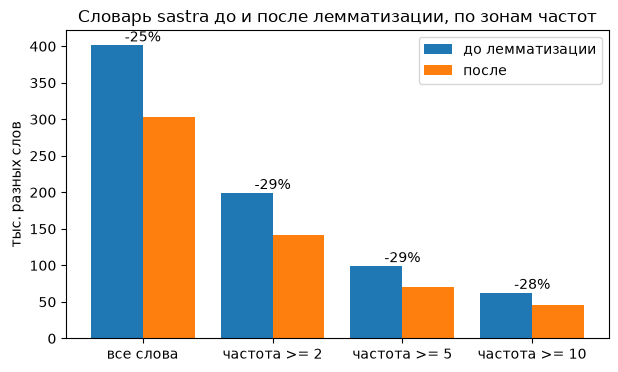

In [15]:
before_cnt, after_cnt = Counter(), Counter()
for ln in open(os.path.join(CLEAN, "corpus_segments_sastra.txt"),
               encoding="utf-8"):
    before_cnt.update(ln.split())
for ln in open(os.path.join(LEMMA, "corpus_segments_sastra.txt"),
               encoding="utf-8"):
    after_cnt.update(ln.split())

thresholds = [1, 2, 5, 10]
labels = ["все слова", "частота >= 2", "частота >= 5", "частота >= 10"]
b_vals = [sum(1 for c in before_cnt.values() if c >= t) / 1000
          for t in thresholds]
a_vals = [sum(1 for c in after_cnt.values() if c >= t) / 1000
          for t in thresholds]

x = range(len(labels))
plt.figure(figsize=(7, 4))
plt.bar([i - 0.2 for i in x], b_vals, width=0.4, label="до лемматизации")
plt.bar([i + 0.2 for i in x], a_vals, width=0.4, label="после")
for i in x:
    plt.text(i, max(b_vals[i], a_vals[i]) + 5,
             f"-{100 * (1 - a_vals[i] / b_vals[i]):.0f}%", ha="center")
plt.xticks(x, labels)
plt.ylabel("тыс. разных слов")
plt.title("Словарь sastra до и после лемматизации, по зонам частот")
plt.legend()
plt.show()

Проверка на трибанке UD Javanese-CSUI с эталонными леммами (файл в eval/). Важно: UD сводит и деривацию (tulisan → tulis, gamelan → gamel), а мы её осознанно оставляем - поэтому такие случаи выносим отдельной строкой «UD сводит глубже», это не ошибка, а разные цели разметки. Смотрим прежде всего на точность сделанных нами замен и на остаточный недобор.

In [16]:
def _der_reduces_to(a, b):
    # достижимо ли b из a снятием ТОЛЬКО деривации (UD сводит глубже нас)?
    frontier, seen = [a], {a}
    for _ in range(3):
        nxt = []
        for w in frontier:
            for c in der_candidates(w):
                if c == b:
                    return True
                if c not in seen and len(c) >= 3:
                    seen.add(c)
                    nxt.append(c)
        frontier = nxt
        if not frontier:
            break
    return False

def evaluate(conllu_path):
    total = correct = chg = ok = part = wr = der_div = miss = 0
    for ln in open(conllu_path, encoding="utf-8"):
        cols = ln.split("\t")
        if len(cols) != 10 or not cols[0].isdigit():
            continue
        form, gold = cols[1].lower(), cols[2].lower()
        if not form.isalpha() or cols[3] in ("PUNCT", "SYM", "NUM", "PROPN"):
            continue
        f, g = normalize(form), normalize(gold)
        p = lem.lemma(f)
        total += 1
        correct += p == g
        if p != f:                              # сделали замену
            chg += 1
            if p == g:
                ok += 1
            elif _der_reduces_to(p, g):
                part += 1                       # сняли инфлексию, UD снял и деривацию
            else:
                wr += 1                         # реально иная замена
        elif g != f:                            # оставили, а UD поменял
            if _der_reduces_to(f, g):
                der_div += 1
            else:
                miss += 1
    print(f"токенов: {total}, точное совпадение с UD: {correct / total:.3f}")
    print(f"наши замены ({chg}): точно {100 * ok / chg:.0f}%, "
          f"частично (UD глубже, деривация) {100 * part / chg:.0f}%, "
          f"иначе {100 * wr / chg:.0f}%")
    print(f"  -> ложных замен от всех токенов: {100 * wr / total:.1f}%")
    print(f"оставили, а UD сменил: деривация {100 * der_div / total:.1f}% "
          f"(осознанно), недобор {100 * miss / total:.1f}% (нет корня)")

if os.path.exists("eval/jv_csui-ud-test.conllu"):
    evaluate("eval/jv_csui-ud-test.conllu")

токенов: 9968, точное совпадение с UD: 0.827
наши замены (1202): точно 50%, частично (UD глубже, деривация) 36%, иначе 13%
  -> ложных замен от всех токенов: 1.6%
оставили, а UD сменил: деривация 5.1% (осознанно), недобор 6.2% (нет корня)


На выходе:
- corpus_clean/ - очищенный корпус
- lexicon/ - корни и частоты
- corpus_lemma/ - очищенный и лемматизированный корпус: в каждом ведре texts/<ведро>/ (тексты по файлам), corpus_text_<ведро>.txt (для SVD) и corpus_segments_<ведро>.txt (для CBoW)
- embeddings/ - словари эмбеддингов SVD и CBoW (считаются ниже)

Основной корпус для эмбеддингов - ведро sastra. Ниже - оба эмбеддинга: SVD (размерность <= 32, по текстовому корпусу) и CBoW (по сегментному).

In [17]:
freqs, slens = {}, {}
for b in BUCKETS:
    p = os.path.join(LEMMA, f"corpus_segments_{b}.txt")
    if not os.path.exists(p):
        continue
    cnt, lens = Counter(), []
    for ln in open(p, encoding="utf-8"):
        toks = ln.split()
        cnt.update(toks)
        lens.append(len(toks))
    freqs[b], slens[b] = cnt, lens

print(f"{'ведро':<9}{'текстов':>9}{'предлож.':>11}{'токенов':>13}"
      f"{'слов(типов)':>13}{'ср.предл.':>11}")
for b in freqs:
    ntexts = len(os.listdir(os.path.join(LEMMA, "texts", b)))
    ntok = sum(freqs[b].values())
    print(f"{b:<9}{ntexts:>9}{len(slens[b]):>11}{ntok:>13}"
          f"{len(freqs[b]):>13}{ntok / len(slens[b]):>11.1f}")

ведро      текстов   предлож.      токенов  слов(типов)  ср.предл.
sastra        2105    2254719     13830816       303119        6.1
arsip          386     181199      1630948        59561        9.0
jurnal         682     299590      3834223       100434       12.8
majalah       2224     126512      1234437        59063        9.8


In [18]:
total = sum(freqs["sastra"].values())
for i, (w, c) in enumerate(freqs["sastra"].most_common(30), 1):
    print(f"{i:>3}. {w:<12} {c:>9}  ({100 * c / total:.2f}%)")

  1. ing             364410  (2.63%)
  2. kang            271503  (1.96%)
  3. PRON1           188849  (1.37%)
  4. ORDINAL1        156351  (1.13%)
  5. ingkang         145021  (1.05%)
  6. sang            108759  (0.79%)
  7. wong             92539  (0.67%)
  8. tan              91100  (0.66%)
  9. lan              90402  (0.65%)
 10. yen              82397  (0.60%)
 11. wus              79941  (0.58%)
 12. sampun           70989  (0.51%)
 13. iku              64820  (0.47%)
 14. punika           57307  (0.41%)
 15. sami             57047  (0.41%)
 16. ana              55569  (0.40%)
 17. dhateng          47974  (0.35%)
 18. wonten           47707  (0.34%)
 19. lajeng           47685  (0.34%)
 20. mring            46234  (0.33%)
 21. saking           46049  (0.33%)
 22. para             44423  (0.32%)
 23. ki               43271  (0.31%)
 24. prabu            43151  (0.31%)
 25. marang           43053  (0.31%)
 26. wau              42928  (0.31%)
 27. ora              42629  (0.31%)
 

Размер корпуса по вёдрам, в миллионах токенов.

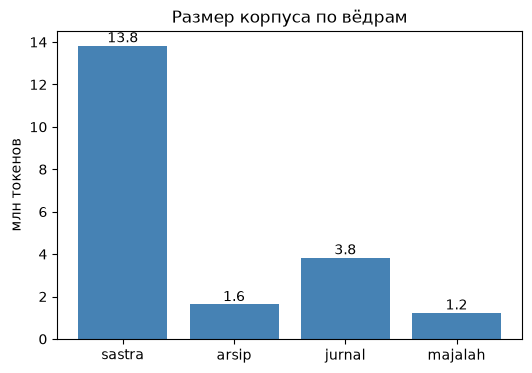

In [19]:
names = list(freqs)
toks = [sum(freqs[b].values()) / 1e6 for b in names]
plt.figure(figsize=(6, 4))
plt.bar(names, toks, color="steelblue")
for i, v in enumerate(toks):
    plt.text(i, v, f"{v:.1f}", ha="center", va="bottom")
plt.ylabel("млн токенов")
plt.title("Размер корпуса по вёдрам")
plt.show()

20 самых частых слов основного корпуса

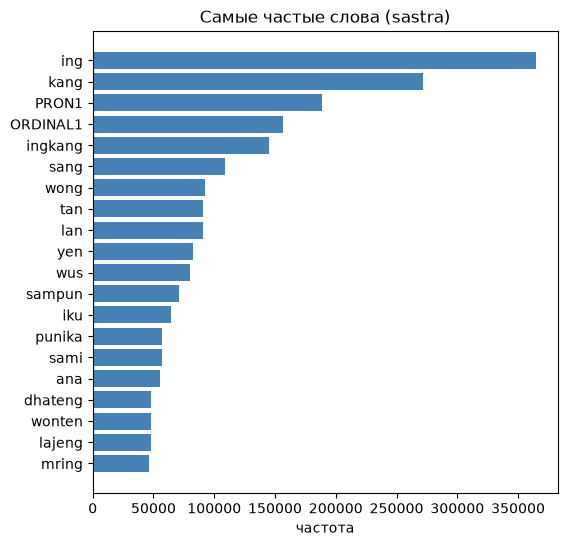

In [20]:
words, cnts = zip(*freqs["sastra"].most_common(20))
plt.figure(figsize=(6, 6))
plt.barh(words, cnts, color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("частота")
plt.title("Самые частые слова (sastra)")
plt.show()

Что дала лемматизация: сколько разных слов было в каждом ведре до неё и сколько осталось после. Разные формы одного корня склеились в одну лемму.

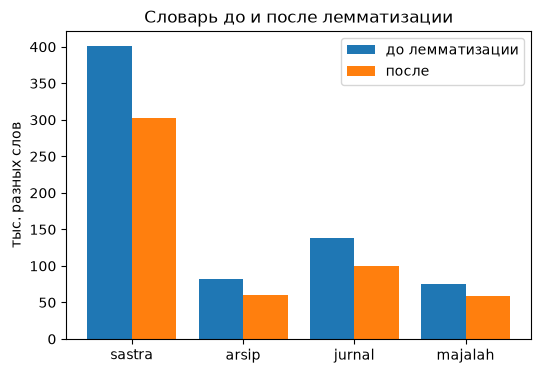

In [21]:
vocab = {}
for ln in open(os.path.join(LEMMA, "_stats.txt"), encoding="utf-8"):
    if "_vocab" in ln:
        b = ln.split("_vocab")[0]
        before, after = ln.split(":")[1].split("->")
        vocab[b] = (int(before), int(after))

names = list(vocab)
x = range(len(names))
plt.figure(figsize=(6, 4))
plt.bar([i - 0.2 for i in x], [vocab[b][0] / 1000 for b in names],
        width=0.4, label="до лемматизации")
plt.bar([i + 0.2 for i in x], [vocab[b][1] / 1000 for b in names],
        width=0.4, label="после")
plt.xticks(x, names)
plt.ylabel("тыс. разных слов")
plt.title("Словарь до и после лемматизации")
plt.legend()
plt.show()

Эффективность лемматизатора по эталону UD, подробно. Раскладываем все слова эталона: какие менять не надо (и не тронули ли мы их зря), какие надо - и что мы с ними сделали. Главное: когда лемматизатор решается тронуть слово, он почти всегда прав (ложных замен ~3%); его слабое место - охват (часть аффиксированных слов не разбирается, потому что корня нет в лексиконе).

 7637 (76.6%)  менять не надо: верно оставили
  607 ( 6.1%)  менять надо: тронули верно
  508 ( 5.1%)  менять надо: осознанно оставили деривацию (UD глубже)
  436 ( 4.4%)  менять надо: тронули, UD свёл глубже (деривация)
  418 ( 4.2%)  менять надо: сознательно оставили (служебное/словарное)
  203 ( 2.0%)  менять надо: не разобрали (корня нет в лексиконе)
   89 ( 0.9%)  менять не надо: ЗРЯ ТРОНУЛИ
   70 ( 0.7%)  менять надо: тронули иначе (расхождение)

из наших замен: точно верных 50%, хороших с частичными 87%


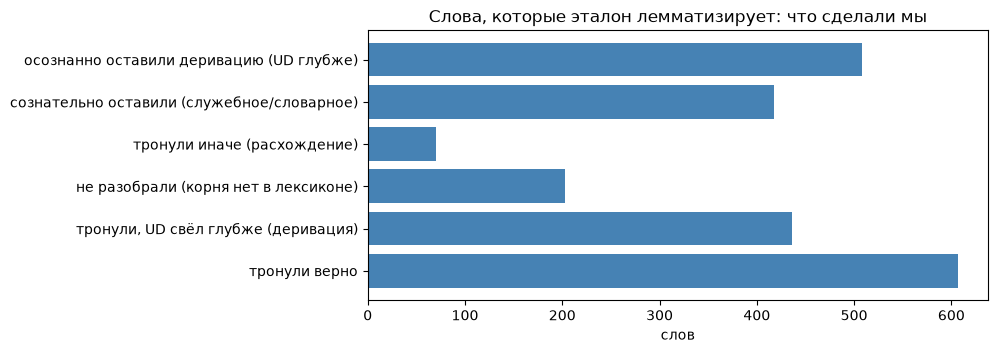

In [22]:
stat = Counter()
for ln in open("eval/jv_csui-ud-test.conllu", encoding="utf-8"):
    cols = ln.split("\t")
    if len(cols) != 10 or not cols[0].isdigit():
        continue
    form, gold = cols[1].lower(), cols[2].lower()
    if not form.isalpha() or cols[3] in ("PUNCT", "SYM", "NUM", "PROPN"):
        continue
    f, g = normalize(form), normalize(gold)
    p = lem.lemma(f)
    if g == f:
        stat["менять не надо: верно оставили" if p == f
             else "менять не надо: ЗРЯ ТРОНУЛИ"] += 1
    elif p == g:
        stat["менять надо: тронули верно"] += 1
    elif p != f:
        if _der_reduces_to(p, g):
            stat["менять надо: тронули, UD свёл глубже (деривация)"] += 1
        else:
            stat["менять надо: тронули иначе (расхождение)"] += 1
    elif _der_reduces_to(f, g):
        stat["менять надо: осознанно оставили деривацию (UD глубже)"] += 1
    elif f in lem.roots or (lem.freq.get(f, 0) >= 5000 and len(f) <= 7) \
            or len(f) < 4:
        stat["менять надо: сознательно оставили (служебное/словарное)"] += 1
    else:
        stat["менять надо: не разобрали (корня нет в лексиконе)"] += 1

total = sum(stat.values())
for k, v in stat.most_common():
    print(f"{v:>5} ({100 * v / total:4.1f}%)  {k}")

changed = sum(v for k, v in stat.items() if "тронули" in k or "ЗРЯ" in k)
good = (stat["менять надо: тронули верно"]
        + stat["менять надо: тронули, UD свёл глубже (деривация)"])
print(f"\nиз наших замен: точно верных "
      f"{100 * stat['менять надо: тронули верно'] / changed:.0f}%, "
      f"хороших с частичными {100 * good / changed:.0f}%")

labels = [k.split(": ")[1] for k in stat if k.startswith("менять надо")]
vals = [stat[k] for k in stat if k.startswith("менять надо")]
plt.figure(figsize=(8, 3.5))
plt.barh(labels, vals, color="steelblue")
plt.title("Слова, которые эталон лемматизирует: что сделали мы")
plt.xlabel("слов")
plt.show()

Известные проблемы и ограничения.

Лемматизатор:
- две фазы, инфлексия снимается, деривация остаётся: tulisan (текст), inuman (напиток), panulisan (писание) - отдельные леммы, не tulis/inum. Это сознательно: для эмбеддингов это разные единицы значения. Поэтому словарь ужимается меньше, чем при «слепом» стемминге, зато не путает смыслы
- принцип «не свёл к корню - не трогай»: формы, чьего корня нет в лексиконе (~22 тыс. корней), остаются как есть - после лемматизации всё равно сотни тысяч разных слов (хапаксы, имена, редкое кави, шум оцифровки)
- ~900 назальных форм (nginum, ngombe...) внесены в словари как заголовки, поэтому к корню (inum) их не сводим - тоже остаются как есть (консервативно)
- формы с paN-...-an (panulisan, pamulangan) недо-сводятся к производному без грамматики - оставляем целиком (безопасный недобор, смысл не страдает)
- частые служебные и лексикализованные слова, которых нет в словарях-источниках (minangka, menawa, negara, melu, mbok...), защищены отдельно (набор JAV + список PROTECT) - иначе их ошибочно разбирали назальные/инфиксные правила (minangka -> mangka). Остаточные неверные замены ~1.6%: имена собственные после lowercase (lamongan -> lamong), иноязычные вкрапления, стяжения гласных на стыке морфем (turu + an = turon), которые мы не разворачиваем

Стили (ngoko/krama):
- грамматику регистров сводим (-e и -ipun дают одну лемму), но корни у штилей разные, поэтому лексические пары остаются раздельными: mangan / nedha / dhahar - три леммы, omah / griya - две. Лексически krama в ngoko сознательно не переводим (соответствия не один-к-одному и зависят от того, о ком речь)
- значит, у эмбеддингов отдельный тест качества: регистровые пары должны получить близкие векторы (проверяется в SVD-секции: cos(ratu,raja)=0.85, cos(mangan,dhahar)=0.62)

Ещё важное:
- перекос состава: большая часть основного корпуса - классический стих XVIII - начала XX века, современный язык представлен слабо. Эмбеддинги получатся «литературно-архаичными»
- дубли произведений: часть классики есть в 2+ изданиях/транскрипциях (Centhini 1912 и 1985-91) - это разные тексты, не копии, но лексика частично задвоена
- стиховые сегменты короткие (в среднем ~6 токенов - строки строф): у крайних слов мало контекста для CBoW, плюс в стихах инверсии ради метра
- шум оцифровки: больше половины словаря - слова, встреченные 1 раз (опечатки, разнобой старых написаний); лечится частотным порогом при обучении эмбеддингов
- старая орфография: букву j (= «й») в довоенных текстах нельзя автоматически отличить от j (= «дж»), поэтому в журнальном ведре часть слов задвоена (kaja / kaya)
- спецтокены ORDINAL1/PRON1 после lowercase попадают в словарь SVD как ordinal1/pron1 (заполнители чисел/местоимений; idf их приглушает)

# SVD-эмбеддинги

По заданию SVD считается на **текстовом** корпусе (1 строка = 1 текст) основного ведра sastra, размерность <= 32. Метод как в `instruction/Preprocessing_SVD_example`:
- `TfidfVectorizer` строит матрицу W (тексты x слова); `token_pattern` оставляет только яванский алфавит, цифры и дефис (отсекает пунктуацию и иноязычные вкрапления), `min_df=5` отсекает шумовые хапаксы;
- `scipy.sparse.linalg.svds(W, k)` даёт разложение; порядок сингулярных значений svds не гарантирует, поэтому сортируем по убыванию;
- эмбеддинги слов = (diag(sigma) @ vt).T, словарь {слово: вектор} сохраняем в `embeddings/svd_sastra_32.npy`.

Свойство SVD: вектор любой размерности m <= k - это первые m компонент готового вектора, пересчёт не нужен.

In [23]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse.linalg import svds

EMB = "embeddings"
os.makedirs(EMB, exist_ok=True)
JAV_TOKEN = r"[a-z][a-z0-9-]+"   # яванский алфавит + цифры + дефис

def make_matrix_W(corpus_path, min_df=5, token_pattern=JAV_TOKEN):
    """W: тексты x слова (TF-IDF), как в примере инструкции."""
    vec = TfidfVectorizer(analyzer="word", min_df=min_df,
                          token_pattern=token_pattern, use_idf=True)
    with open(corpus_path, encoding="utf-8") as f:
        W = vec.fit_transform(f)
    return W, vec.get_feature_names_out()

def apply_svd(W, k):
    """SVD ранга k; svds не гарантирует ни порядок, ни знак - сортируем по
    убыванию, random_state фиксируем для воспроизводимости."""
    u, sigma, vt = svds(W, k, random_state=0)
    order = np.flip(np.argsort(sigma))
    sigma, vt = sigma[order], vt[order]
    assert sigma.shape == (k,) and vt.shape == (k, W.shape[1])
    return np.dot(np.diag(sigma), vt).T, sigma     # (слова x k), sigma

K = 32   # размерность по заданию <= 32
W, words = make_matrix_W(os.path.join(LEMMA, "corpus_text_sastra.txt"))
vv, sigma = apply_svd(W, K)
svd_dict = {w: v for w, v in zip(words, vv)}
np.save(os.path.join(EMB, f"svd_sastra_{K}.npy"), svd_dict)

print(f"W (тексты x слова): {W.shape}, словарь: {len(words)}")
print(f"эмбеддинги: {vv.shape} -> {EMB}/svd_sastra_{K}.npy")
print("топ-8 сингулярных значений:", np.round(sigma[:8], 2))

W (тексты x слова): (2105, 57777), словарь: 57777
эмбеддинги: (57777, 32) -> embeddings/svd_sastra_32.npy
топ-8 сингулярных значений: [21.48  9.37  8.67  7.68  5.59  4.95  4.72  4.47]


Валидация (как в примере-нутбуке): проверяем свойство среза и смысл. Соседи по косинусу должны быть тематически связаны (royal/epic-лексика, война, дом). Отдельно: регистровые пары, которые мы намеренно держим РАЗНЫМИ леммами (krama/ngoko: banyu/toya, mangan/dhahar, ratu/raja), должны получить близкие вектора - это подтверждает решение не сливать их в одну лемму (эмбеддинг сам ставит их рядом, а различие написания сохранено).

In [24]:
# свойство SVD: вектор размерности m <= K - это первые m компонент
print("'ratu': K=32 ->", np.round(svd_dict["ratu"][:4], 3), "...")
print("'ratu': m=2  ->", np.round(svd_dict["ratu"][:2], 3), "(те же первые 2)")

# ближайшие соседи по косинусу
norm = vv / (np.linalg.norm(vv, axis=1, keepdims=True) + 1e-9)
widx = {w: i for i, w in enumerate(words)}

def neighbors(word, topn=8):
    if word not in widx:
        return f"'{word}' нет в словаре"
    sims = norm @ norm[widx[word]]
    return ", ".join(f"{words[j]}({sims[j]:.2f})"
                     for j in np.argsort(-sims)[1:topn + 1])

print("\nближайшие соседи (тематические кластеры):")
for q in ["ratu", "prabu", "perang", "banyu", "omah", "putri"]:
    print(f"  {q:>7}: {neighbors(q)}")

# регистровые пары держим разными леммами - но вектора должны быть близки
def cos(a, b):
    return float(norm[widx[a]] @ norm[widx[b]]) \
        if a in widx and b in widx else None

print("\nрегистровые пары (одно значение, разные леммы) - косинус:")
for a, b in [("ratu", "raja"), ("mangan", "dhahar"), ("banyu", "toya"),
             ("omah", "griya"), ("wong", "tiyang")]:
    v = cos(a, b)
    print(f"  cos({a}, {b}) = {v:.2f}" if v is not None else f"  {a}/{b}: n/a")

'ratu': K=32 -> [ 0.811 -0.042 -0.078 -0.183] ...
'ratu': m=2  -> [ 0.811 -0.042] (те же первые 2)

ближайшие соседи (тематические кластеры):
     ratu: saleksa(0.92), patutan(0.88), ulubalang(0.87), eram(0.87), leksa(0.86), buja(0.86), ngajani(0.86), anyakrawati(0.86)
    prabu: sayembara(0.90), kadhaton(0.89), rajaputra(0.86), prameswari(0.86), andhustha(0.85), kabaranang(0.85), sakadang(0.85), prabon(0.85)
   perang: sasirep(0.89), panempuh(0.85), obong(0.84), anulungi(0.82), sasedherek(0.79), ketaton(0.79), paprangan(0.79), ijen-ijenan(0.79)
    banyu: abang(0.92), rupa(0.91), ireng(0.91), susuh(0.90), aran(0.90), ijo(0.89), asin(0.88), kodhok(0.87)
     omah: dhisik(0.96), entek(0.96), cedhak(0.95), krungu(0.95), enom(0.94), tau(0.94), bengi(0.93), bojo(0.93)
    putri: nelasah(0.89), kantaka(0.89), aniyup(0.88), linungsir-lungsir(0.88), orem(0.87), retna(0.87), ibu(0.86), bayarsa(0.86)

регистровые пары (одно значение, разные леммы) - косинус:
  cos(ratu, raja) = 0.85
  cos(manga

# CBoW-эмбеддинги

По заданию CBoW считается на **сегментном** корпусе (1 строка = 1 предложение) ведра sastra. Метод как в `instruction/word2vec`: `gensim Word2Vec` с `sg=0` (это и есть CBoW - предсказание слова по контексту). Параметры: `vector_size=100` (для SVD был лимит <= 32, у CBoW он не задан - берём стандарт word2vec 100, легко поменять), `window=5`, `min_count=5` (отсекает редкие/шумовые). Для воспроизводимости `workers=1, seed=0` (полная воспроизводимость требует ещё запуска с `PYTHONHASHSEED=0`). Словарь {слово: вектор} сохраняем текстом (формат примера: первая строка «N dim») и бинарно `.kv`.

In [25]:
from gensim.models import Word2Vec

CBOW_DIM = 100
with open(os.path.join(LEMMA, "corpus_segments_sastra.txt"), encoding="utf-8") as f:
    seg_sents = [ln.split() for ln in f if ln.strip()]

# sg=0 -> CBoW; workers=1 + seed=0 (+ запуск с PYTHONHASHSEED=0) для воспроизводимости
cbow = Word2Vec(sentences=seg_sents, vector_size=CBOW_DIM, window=5,
                min_count=5, sg=0, epochs=5, workers=1, seed=0)
cbow_dict = {w: cbow.wv[w] for w in cbow.wv.key_to_index}

def save_dictionary(fname, dictionary, dim):
    # формат примера-нутбука: первая строка "N dim", затем "слово v1 v2 ..."
    with open(fname, "w", encoding="utf-8") as f:
        f.write(f"{len(dictionary)} {dim}\n")
        for w, v in dictionary.items():
            f.write(w + " " + " ".join(map(str, v)) + "\n")

save_dictionary(os.path.join(EMB, f"cbow_sastra_{CBOW_DIM}.txt"), cbow_dict, CBOW_DIM)
cbow.wv.save(os.path.join(EMB, f"cbow_sastra_{CBOW_DIM}.kv"))
print(f"CBoW: предложений {len(seg_sents)}, словарь {len(cbow_dict)} слов, "
      f"размерность {CBOW_DIM}")
print(f"сохранено: {EMB}/cbow_sastra_{CBOW_DIM}.txt (+ .kv для быстрой загрузки)")

CBoW: предложений 2254719, словарь 70271 слов, размерность 100
сохранено: embeddings/cbow_sastra_100.txt (+ .kv для быстрой загрузки)


Валидация CBoW (как у SVD): ближайшие соседи и регистровые пары. У CBoW соседи - это уже настоящие синонимы и семантические родственники (резче, чем тематические кластеры SVD), потому что модель учит контекст слова в предложении, а не со-встречаемость в целых текстах. Регистровые пары снова близки (подтверждает, что держать krama/ngoko разными леммами правильно).

In [26]:
print("CBoW ближайшие соседи (синонимы/семантика):")
for q in ["ratu", "prabu", "perang", "banyu", "omah", "putri", "tresna"]:
    if q in cbow.wv:
        s = cbow.wv.most_similar(q, topn=8)
        print(f"  {q:>7}: " + ", ".join(f"{w}({c:.2f})" for w, c in s))

print("\nрегистровые пары (одно значение, разные леммы) - косинус:")
for a, b in [("ratu", "raja"), ("mangan", "dhahar"), ("banyu", "toya"),
             ("omah", "griya"), ("wong", "tiyang")]:
    if a in cbow.wv and b in cbow.wv:
        print(f"  cos({a}, {b}) = {cbow.wv.similarity(a, b):.2f}")

CBoW ближайшие соседи (синонимы/семантика):
     ratu: rathu(0.81), narpati(0.62), raja(0.60), ksatriya(0.60), narendra(0.57), nata(0.56), nerpati(0.52), senapati(0.51)
    prabu: aprabu(0.73), nata(0.66), thatha(0.66), rajaputra(0.65), widura(0.64), duryudana(0.64), bisma(0.64), arjuna(0.62)
   perang: prang(0.83), yuda(0.72), ayuda(0.67), aprang(0.66), paprangan(0.64), kraman(0.63), aperang(0.62), jurit(0.62)
    banyu: sagara(0.67), geni(0.67), segara(0.66), warih(0.65), buthek(0.65), getih(0.64), endhut(0.62), iwak(0.62)
     omah: panggonan(0.72), pomahan(0.68), paturon(0.68), desa(0.68), lungguhan(0.67), dhayoh(0.67), nyambutgawe(0.67), ngendi-endi(0.66)
    putri: prameswari(0.71), wanodya(0.66), rajaputri(0.65), garwa(0.63), dewi(0.63), retna(0.63), dyah(0.62), rajaputra(0.62)
   tresna: trisna(0.82), katresnan(0.76), welasan(0.74), sengit(0.73), asih(0.72), gething(0.70), sih(0.69), pangrengkuh(0.66)

регистровые пары (одно значение, разные леммы) - косинус:
  cos(ratu, raja) 